# Aporte del EOG y el EMG, dinámica de transiciones y partición por sujeto

**Autor: Javier Andrés Marín Gallón**

Los análisis previos del equipo caracterizaron el desbalance de clases, la calidad de los datos y
la relación entre el EEG y la edad. Este cuaderno se ocupa de tres preguntas que quedaban abiertas
y que condicionan directamente el diseño del modelo:

1. **¿Qué aportan realmente el EOG y el EMG?** El enunciado exige una plataforma que acepte
   combinaciones de canales (EEG solo, EEG+EOG, EEG+EMG, …). Hasta ahora solo se ha explorado el EEG,
   así que no sabemos si las otras dos modalidades justifican el costo de soportarlas.
2. **¿El hipnograma es una secuencia o una bolsa de épocas independientes?** Si las etapas tienen
   memoria, un clasificador que mira cada época de 30 s por separado está desperdiciando información.
3. **¿Cómo partir los datos sin fuga de información?** El enunciado pide partir por sujeto y no por
   época. Conviene medir el tamaño del error antes de darlo por sentado.

El cuaderno sigue la convención del equipo: los datos se leen de `../../Data` (`dvc pull`).


# 1. Lectura de datos


## 1.1 Librerías y configuración


In [1]:
import glob
import os
import warnings

import mne
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy.signal import welch
from scipy.stats import rankdata

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Guarda cada figura de plotly en dos formatos: interactivo (Jupyter) y PNG (GitHub, que no ejecuta JS)
pio.renderers.default = "plotly_mimetype+png"

# Los datos pueden estar en la carpeta compartida del repositorio (dvc pull) o en una copia local
RAIZ_DATOS = next(ruta for ruta in ("../../Data", "data") if os.path.isdir(ruta + "/sleep-cassette"))
DATA_DIR = RAIZ_DATOS + "/sleep-cassette"
SUBJECTS_XLS = RAIZ_DATOS + "/SC-subjects.xls"

DURACION_EPOCA = 30.0  # segundos, según el estándar de estadificación

# Equivalencia entre la nomenclatura del hipnograma (Rechtschaffen & Kales) y los estadios AASM.
# Los estadios 3 y 4 se colapsan en N3, como indica el enunciado del proyecto.
ETAPAS = {"Sleep stage W": "W", "Sleep stage 1": "N1", "Sleep stage 2": "N2",
          "Sleep stage 3": "N3", "Sleep stage 4": "N3", "Sleep stage R": "REM",
          "Movement time": "M", "Sleep stage ?": "?"}

ORDEN = ["W", "N1", "N2", "N3", "REM"]
COLOR = {"W": "#8c8c8c", "N1": "#f2a03d", "N2": "#2a78d6", "N3": "#1b3a7a", "REM": "#d6425a"}


## 1.2 Inventario de registros


In [2]:
def identificar(ruta):
    """SC4001E0-PSG.edf -> sujeto 0, noche 1. El prefijo de 7 caracteres une PSG e hipnograma."""
    nombre = os.path.basename(ruta)
    return {"clave": nombre[:7], "subject": int(nombre[3:5]), "night": int(nombre[5])}


psg_files = {identificar(r)["clave"]: r for r in sorted(glob.glob(DATA_DIR + "/*-PSG.edf"))}
hyp_files = sorted(glob.glob(DATA_DIR + "/*-Hypnogram.edf"))

# El inventario se ancla en el hipnograma: es lo que define qué registros están etiquetados.
registros = pd.DataFrame([{**identificar(r), "hyp": r, "psg": psg_files.get(identificar(r)["clave"])}
                          for r in hyp_files])

subjects = pd.read_excel(SUBJECTS_XLS).rename(columns={"sex (F=1)": "sex_code"})
subjects["sexo"] = subjects["sex_code"].map({1: "F", 2: "M"})
registros = registros.merge(subjects[["subject", "night", "age", "sexo"]], on=["subject", "night"], how="left")

con_senal = registros["psg"].notna()
print(f"Registros con hipnograma: {len(registros)}  |  sujetos distintos: {registros['subject'].nunique()}")
print(f"Registros con señal PSG descargada: {con_senal.sum()}")
registros[["clave", "subject", "night", "age", "sexo"]].head(10)


Registros con hipnograma: 153  |  sujetos distintos: 78
Registros con señal PSG descargada: 14


,clave,subject,night,age,sexo
0,SC4001E,0,1,33,F
1,SC4002E,0,2,33,F
2,SC4011E,1,1,33,F
3,SC4012E,1,2,33,F
4,SC4021E,2,1,26,F
5,SC4022E,2,2,26,F
6,SC4031E,3,1,26,F
7,SC4032E,3,2,26,F
8,SC4041E,4,1,34,F
9,SC4042E,4,2,34,F


El cuaderno distingue deliberadamente dos alcances. Los análisis de las secciones 2, 4 y 5 solo
necesitan el hipnograma —unos pocos KB por registro— y se hacen sobre **todos** los registros
etiquetados. La sección 3 abre las señales completas, que pesan unos 50 MB cada una, y por eso se
limita a un subconjunto declarado explícitamente. Quien haya hecho `dvc pull` completo obtendrá los
mismos resultados con más registros en la sección 3; el resto no cambia.


## 1.3 Del hipnograma a la secuencia de épocas


In [3]:
def hipnograma_por_epoca(ruta_hyp):
    """Expande las anotaciones a una fila por época de 30 s.

    Una anotación puede cubrir varias épocas (por ejemplo 40 minutos de vigilia), así que
    contar anotaciones no equivale a contar épocas.
    """
    anotaciones = mne.read_annotations(ruta_hyp)
    filas = []
    for inicio, duracion, descripcion in zip(anotaciones.onset, anotaciones.duration,
                                             anotaciones.description):
        etapa = ETAPAS.get(descripcion, "?")
        for k in range(int(round(duracion / DURACION_EPOCA))):
            filas.append((inicio + k * DURACION_EPOCA, etapa))
    return pd.DataFrame(filas, columns=["onset_s", "etapa"])


def ventana_de_sueno(hipnograma, margen_min=30):
    """Recorta la vigilia prolongada de los extremos, conservando un margen alrededor del sueño.

    Sleep-EDF graba día y noche completos: sin este recorte la clase W domina artificialmente.
    Se mantiene el criterio que ya usó el equipo (30 minutos de margen).
    """
    dormido = hipnograma[~hipnograma["etapa"].isin(["W", "?"])]
    if dormido.empty:
        return hipnograma.iloc[0:0]
    margen = margen_min * 60
    inicio = dormido["onset_s"].iloc[0] - margen
    fin = dormido["onset_s"].iloc[-1] + margen
    return hipnograma[(hipnograma["onset_s"] >= inicio) & (hipnograma["onset_s"] <= fin)].reset_index(drop=True)


secuencias = {}
for fila in registros.itertuples():
    completo = hipnograma_por_epoca(fila.hyp)
    secuencias[fila.clave] = {"completo": completo, "ventana": ventana_de_sueno(completo)}

epocas = pd.concat(
    [s["ventana"].assign(clave=clave) for clave, s in secuencias.items()], ignore_index=True
).merge(registros[["clave", "subject", "night", "age", "sexo"]], on="clave")

print(f"Épocas dentro de la ventana de sueño: {len(epocas):,}")
print(f"Épocas en el registro completo:       {sum(len(s['completo']) for s in secuencias.values()):,}")


Épocas dentro de la ventana de sueño: 195,995
Épocas en el registro completo:       440,640


# 2. El hipnograma es una secuencia, no una bolsa de épocas

El modelo que plantea el enunciado recibe una época de 30 s y devuelve un estadio. Esa formulación
trata cada época como independiente. Antes de aceptarla conviene medir cuánta información hay en el
orden temporal.


## 2.1 Matriz de transiciones


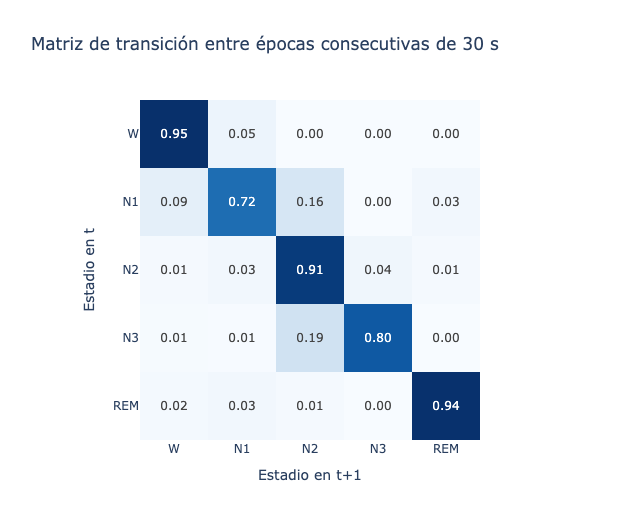

Probabilidad de permanecer en el mismo estadio:
    W: 0.946
   N1: 0.724
   N2: 0.908
   N3: 0.797
  REM: 0.942

Global: 0.898 de las épocas repiten el estadio anterior.


In [4]:
def transiciones(secuencia):
    """Cuenta pares (etapa en t, etapa en t+1) para épocas consecutivas y válidas."""
    etapas = secuencia["etapa"].to_numpy()
    tiempos = secuencia["onset_s"].to_numpy()
    contiguas = np.isclose(np.diff(tiempos), DURACION_EPOCA)
    origen, destino = etapas[:-1][contiguas], etapas[1:][contiguas]
    validas = np.isin(origen, ORDEN) & np.isin(destino, ORDEN)
    return pd.DataFrame({"desde": origen[validas], "hacia": destino[validas]})


pares = pd.concat([transiciones(s["ventana"]) for s in secuencias.values()], ignore_index=True)

conteo = pd.crosstab(pares["desde"], pares["hacia"]).reindex(index=ORDEN, columns=ORDEN, fill_value=0)
matriz = conteo.div(conteo.sum(axis=1), axis=0)  # probabilidad condicional por fila

fig = px.imshow(matriz, x=ORDEN, y=ORDEN, text_auto=".2f", color_continuous_scale="Blues",
                labels={"x": "Estadio en t+1", "y": "Estadio en t", "color": "P(t+1 | t)"},
                title="Matriz de transición entre épocas consecutivas de 30 s")
fig.update_layout(width=620, height=520, coloraxis_showscale=False)
fig.show()

permanece = np.diag(matriz.to_numpy()).round(3)
print("Probabilidad de permanecer en el mismo estadio:")
for etapa, p in zip(ORDEN, permanece):
    print(f"  {etapa:>3}: {p:.3f}")
print(f"\nGlobal: {(pares['desde'] == pares['hacia']).mean():.3f} de las épocas repiten el estadio anterior.")


La diagonal domina la matriz: cerca del 90 % de las épocas repiten el estadio anterior, así que el
estadio previo por sí solo ya es un predictor fuerte. Dos detalles importan para el modelado:

- **N1 es el estadio menos persistente** (≈0,72 frente a 0,91–0,95 de los demás) y el que más se
  reparte hacia N2 y hacia W. Es un estado de paso, y es justamente la clase que el enunciado señala
  como problemática.
- **La transición fuera de la diagonal más frecuente es N3 → N2** (≈0,19). El sueño profundo no forma
  bloques largos y limpios sino que alterna con N2, lo cual anticipa que esa también será una
  frontera confusa para el clasificador.


## 2.2 Duración de los episodios


,episodios,mediana_epocas,p90_epocas,mediana_min,p90_min
etapa,,,,,
W,3696,2.0,60.0,1.0,30.0
N1,5944,2.0,8.0,1.0,4.0
N2,6378,4.0,30.0,2.0,15.0
N3,2663,1.0,11.0,0.5,5.5
REM,1560,10.0,42.0,5.0,21.0


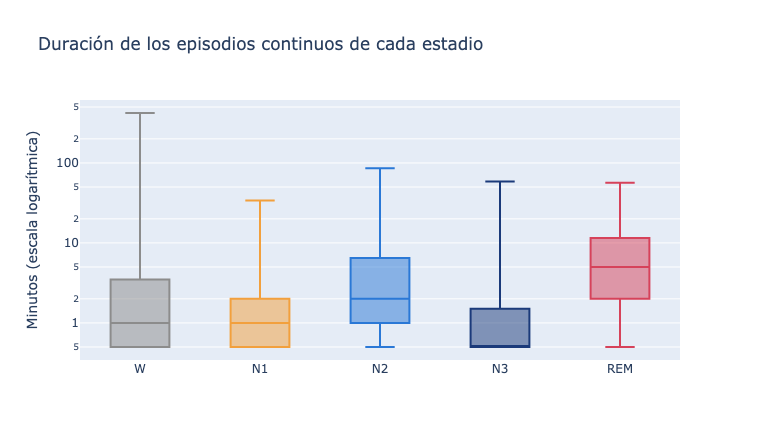

In [5]:
def episodios(secuencia):
    """Longitud (en épocas) de cada tramo contiguo del mismo estadio."""
    etapas = secuencia["etapa"].to_numpy()
    if len(etapas) == 0:
        return pd.DataFrame(columns=["etapa", "epocas"])
    cambio = np.r_[True, etapas[1:] != etapas[:-1]]
    grupos = np.cumsum(cambio)
    tabla = pd.DataFrame({"etapa": etapas, "grupo": grupos})
    resumen = tabla.groupby("grupo").agg(etapa=("etapa", "first"), epocas=("etapa", "size"))
    return resumen[resumen["etapa"].isin(ORDEN)].reset_index(drop=True)


bloques = pd.concat([episodios(s["ventana"]) for s in secuencias.values()], ignore_index=True)
bloques["minutos"] = bloques["epocas"] * DURACION_EPOCA / 60

resumen_bloques = (bloques.groupby("etapa")
                   .agg(episodios=("epocas", "size"),
                        mediana_epocas=("epocas", "median"),
                        p90_epocas=("epocas", lambda x: x.quantile(0.9)),
                        mediana_min=("minutos", "median"),
                        p90_min=("minutos", lambda x: x.quantile(0.9)))
                   .reindex(ORDEN).round(2))
display(resumen_bloques)

fig = px.box(bloques[bloques["etapa"].isin(ORDEN)], x="etapa", y="minutos", color="etapa",
             category_orders={"etapa": ORDEN}, color_discrete_map=COLOR, points=False,
             title="Duración de los episodios continuos de cada estadio")
fig.update_yaxes(type="log", title="Minutos (escala logarítmica)")
fig.update_layout(width=760, height=440, showlegend=False, xaxis_title="")
fig.show()


Los episodios de REM son con diferencia los más sostenidos (mediana de 10 épocas, 5 minutos), mientras
que N1 y N3 son cortos y fragmentados: la mediana de N1 es de 2 épocas y la de N3 de una sola. Es
decir, el sueño profundo no llega en bloques largos, sino en tramos breves intercalados con N2, lo que
concuerda con la transición N3 → N2 de la matriz anterior.

La lectura para el modelado es doble. Por un lado, un modelo con contexto temporal —o un simple
suavizado posterior del hipnograma— tiene margen para corregir predicciones aisladas que son
fisiológicamente implausibles. Por otro, ese suavizado debe aplicarse con cuidado: una ventana
demasiado ancha borraría precisamente los episodios cortos de N1 y N3, que son reales y no ruido.


## 2.3 Dónde cae cada estadio dentro de la noche


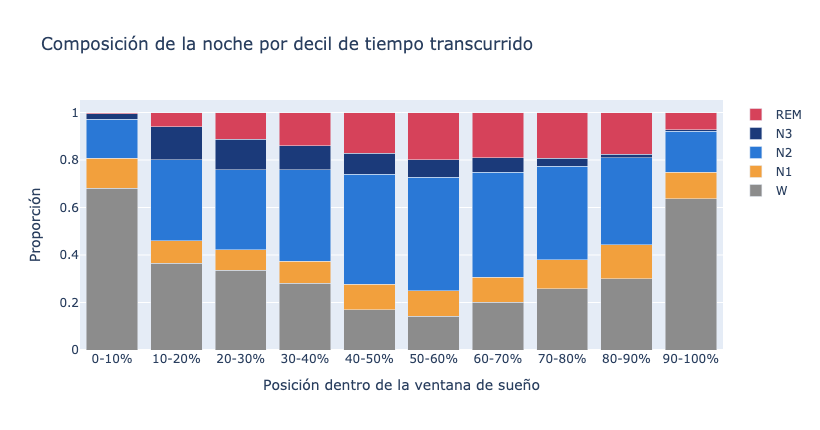

In [6]:
posicion = epocas[epocas["etapa"].isin(ORDEN)].copy()
posicion["t_rel"] = posicion.groupby("clave")["onset_s"].transform(
    lambda s: (s - s.min()) / max(s.max() - s.min(), 1))
posicion["decil"] = (posicion["t_rel"] * 10).clip(0, 9.999).astype(int)

perfil = (pd.crosstab(posicion["decil"], posicion["etapa"], normalize="index")
          .reindex(columns=ORDEN, fill_value=0))

fig = go.Figure()
for etapa in ORDEN:
    fig.add_bar(x=[f"{d*10}-{(d+1)*10}%" for d in perfil.index], y=perfil[etapa],
                name=etapa, marker_color=COLOR[etapa])
fig.update_layout(barmode="stack", width=820, height=430,
                  title="Composición de la noche por decil de tiempo transcurrido",
                  xaxis_title="Posición dentro de la ventana de sueño", yaxis_title="Proporción")
fig.show()


El sueño profundo (N3) se concentra en la primera mitad de la noche y el REM crece hacia el final.
La posición relativa dentro del registro es, por lo tanto, una variable informativa que está
disponible sin costo y que ningún compañero había incorporado. Conviene evaluarla como característica
adicional, teniendo en cuenta que solo es utilizable si la plataforma recibe la noche completa y no
épocas sueltas.


# 3. ¿Qué aportan el EOG y el EMG?

El requisito de despliegue obliga a soportar varias combinaciones de canales. Esta sección mide qué
gana el modelo por cada modalidad añadida.


## 3.1 Qué hay realmente en cada canal


In [7]:
def frecuencias_nativas(ruta_psg):
    """Lee la cabecera EDF para obtener la frecuencia real de cada canal.

    MNE homogeneiza las frecuencias al abrir el archivo (remuestrea todo a la más alta), así que
    `raw.info['sfreq']` esconde el hecho de que los canales no se registraron al mismo ritmo.
    La cabecera EDF sí lo conserva: 256 bytes de encabezado general y 256 por señal.
    """
    with open(ruta_psg, "rb") as f:
        cabecera = f.read(256)
        n_senales = int(cabecera[252:256])
        bloque = f.read(256 * n_senales)

    duracion_registro = float(cabecera[244:252])
    etiquetas = [bloque[i * 16:(i + 1) * 16].decode("ascii").strip() for i in range(n_senales)]

    # Campos por señal antes del número de muestras: etiqueta 16, transductor 80, unidad 8,
    # min/max físico 8+8, min/max digital 8+8, prefiltrado 80  ->  216 bytes por señal
    inicio = n_senales * 216
    muestras = [int(bloque[inicio + i * 8:inicio + (i + 1) * 8]) for i in range(n_senales)]

    return pd.DataFrame({"canal": etiquetas,
                         "Hz_nativos": [m / duracion_registro for m in muestras]})


nativas = frecuencias_nativas(registros.loc[registros["psg"].notna(), "psg"].iloc[0])
nativas["muestras_por_epoca_30s"] = (nativas["Hz_nativos"] * DURACION_EPOCA).astype(int)
display(nativas)

leido_por_mne = mne.io.read_raw_edf(registros.loc[registros["psg"].notna(), "psg"].iloc[0], preload=False)
print(f"Frecuencia que reporta MNE tras homogeneizar: {leido_por_mne.info['sfreq']:.0f} Hz")


,canal,Hz_nativos,muestras_por_epoca_30s
0,EEG Fpz-Cz,100.0,3000
1,EEG Pz-Oz,100.0,3000
2,EOG horizontal,100.0,3000
3,Resp oro-nasal,1.0,30
4,EMG submental,1.0,30
5,Temp rectal,1.0,30
6,Event marker,1.0,30


Frecuencia que reporta MNE tras homogeneizar: 100 Hz


Aquí aparece la restricción más importante para el diseño de la plataforma: **EEG y EOG se registran
a 100 Hz, pero el EMG submentoniano está a 1 Hz**. Una época de 30 segundos contiene 3000 muestras de
EEG y solo 30 de EMG.

La consecuencia práctica es que el EMG de esta base de datos **no permite análisis espectral**: a 1 Hz
la frecuencia de Nyquist es 0,5 Hz, muy por debajo de la banda de interés del EMG (20–100 Hz). Lo que
queda es una envolvente de amplitud ya rectificada por el equipo de adquisición. Sigue siendo útil
—la atonía muscular es el marcador clásico del REM— pero descarta arquitecturas que traten al EMG
como una señal cruda comparable al EEG, y obliga a tratarlo como un canal de características, no como
una entrada más al mismo bloque convolucional.

Conviene subrayarlo porque es fácil pasarlo por alto: MNE devuelve el EMG ya remuestreado a 100 Hz,
de modo que en el arreglo aparecen 3000 valores por época. Son valores interpolados; la información
real sigue siendo de 30 muestras.


## 3.2 Características por modalidad


In [8]:
# Abrir las señales es lo costoso del cuaderno: se limita a un subconjunto, declarado explícitamente.
con_psg = registros[registros["psg"].notna()]
N_REGISTROS_SENAL = min(12, len(con_psg))
BANDAS = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 12), "sigma": (12, 16), "beta": (16, 30)}


def caracteristicas_registro(fila, secuencia):
    """Extrae, por época válida, un descriptor de cada modalidad: EEG espectral, EOG y EMG de amplitud."""
    raw = mne.io.read_raw_edf(fila.psg, preload=False)
    disponibles = raw.ch_names

    canal_eeg = "EEG Fpz-Cz"
    canal_eog = next((c for c in disponibles if c.startswith("EOG")), None)
    canal_emg = next((c for c in disponibles if c.startswith("EMG")), None)

    # Cargar solo los tres canales de interés evita traer a memoria la noche completa de 7 señales
    raw.pick([c for c in (canal_eeg, canal_eog, canal_emg) if c]).load_data()
    fs = raw.info["sfreq"]

    eeg = raw.get_data(picks=[canal_eeg])[0]
    eog = raw.get_data(picks=[canal_eog])[0] if canal_eog else None
    emg = raw.get_data(picks=[canal_emg])[0] if canal_emg else None

    n = int(fs * DURACION_EPOCA)
    filas = []
    for onset, etapa in zip(secuencia["onset_s"], secuencia["etapa"]):
        if etapa not in ORDEN:
            continue
        i = int(onset * fs)
        if i + n > len(eeg):
            continue

        f, pxx = welch(eeg[i:i + n], fs=fs, nperseg=int(fs * 4))
        total = pxx[(f >= 0.5) & (f <= 30)].sum()
        registro = {"clave": fila.clave, "subject": fila.subject, "onset_s": onset, "etapa": etapa}
        for banda, (lo, hi) in BANDAS.items():
            registro[f"eeg_{banda}"] = pxx[(f >= lo) & (f < hi)].sum() / total if total else np.nan

        if eog is not None:
            seg = eog[i:i + n]
            f_o, p_o = welch(seg, fs=fs, nperseg=int(fs * 4))
            registro["eog_amplitud"] = seg.std()
            # Los movimientos oculares del REM son rápidos frente a los del adormecimiento (lentos)
            registro["eog_lento_0.3_1Hz"] = p_o[(f_o >= 0.3) & (f_o < 1)].sum()
            registro["eog_rapido_1_5Hz"] = p_o[(f_o >= 1) & (f_o < 5)].sum()

        if emg is not None:
            seg = emg[i:i + n]
            registro["emg_amplitud"] = seg.std()
            registro["emg_nivel"] = np.abs(seg).mean()

        filas.append(registro)

    del raw
    return pd.DataFrame(filas)


tablas = []
for fila in con_psg.head(N_REGISTROS_SENAL).itertuples():
    tablas.append(caracteristicas_registro(fila, secuencias[fila.clave]["ventana"]))
    print(f"procesado {fila.clave}", end="  ")

rasgos = pd.concat(tablas, ignore_index=True)
print(f"\n\nÉpocas con características: {len(rasgos):,} de {rasgos['clave'].nunique()} registros")
rasgos.head()


procesado SC4001E  

procesado SC4002E  

procesado SC4011E  

procesado SC4012E  

procesado SC4021E  

...

procesado SC4041E  

procesado SC4042E  

procesado SC4051E  

procesado SC4052E  

Épocas con características: 12,507 de 12 registros


,clave,subject,onset_s,etapa,eeg_delta,eeg_theta,eeg_alpha,eeg_sigma,eeg_beta,eog_amplitud,eog_lento_0.3_1Hz,eog_rapido_1_5Hz,emg_amplitud,emg_nivel
0,SC4001E,0,28830.0,W,0.877151,0.083513,0.010756,0.008952,0.019340,0.000047,2.890736e-09,2.233293e-09,6.144451e-08,0.000003
1,SC4001E,0,28860.0,W,0.897759,0.076784,0.007320,0.003494,0.014271,0.000071,7.838437e-09,3.267441e-09,5.685477e-08,0.000003
2,SC4001E,0,28890.0,W,0.908291,0.075759,0.005523,0.002547,0.007734,0.000085,1.245356e-08,6.618202e-09,6.529823e-08,0.000003
3,SC4001E,0,28920.0,W,0.886594,0.078160,0.008368,0.006192,0.020426,0.000101,2.042207e-08,5.374268e-09,4.725029e-08,0.000003
4,SC4001E,0,28950.0,W,0.898478,0.074151,0.008056,0.004896,0.014187,0.000088,1.535601e-08,3.786764e-09,6.472611e-08,0.000003


## 3.3 Separabilidad por modalidad


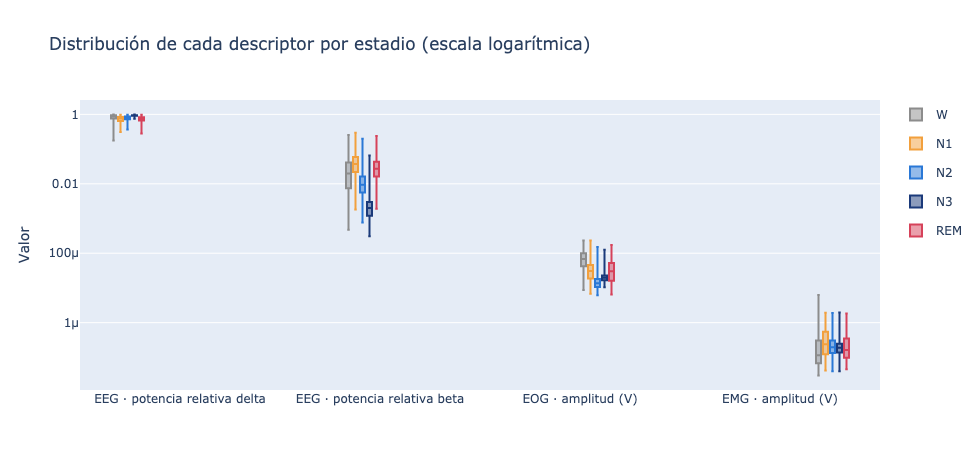

In [9]:
MUESTRA = {"eeg_delta": "EEG · potencia relativa delta", "eeg_beta": "EEG · potencia relativa beta",
           "eog_amplitud": "EOG · amplitud (V)", "emg_amplitud": "EMG · amplitud (V)"}

fig = go.Figure()
disponibles = [c for c in MUESTRA if c in rasgos.columns]
for i, columna in enumerate(disponibles):
    for etapa in ORDEN:
        valores = rasgos.loc[rasgos["etapa"] == etapa, columna].dropna()
        fig.add_box(y=valores, x=[MUESTRA[columna]] * len(valores), name=etapa,
                    marker_color=COLOR[etapa], boxpoints=False, legendgroup=etapa,
                    showlegend=(i == 0))
fig.update_layout(boxmode="group", width=980, height=470, yaxis_type="log",
                  title="Distribución de cada descriptor por estadio (escala logarítmica)",
                  yaxis_title="Valor", xaxis_title="")
fig.show()


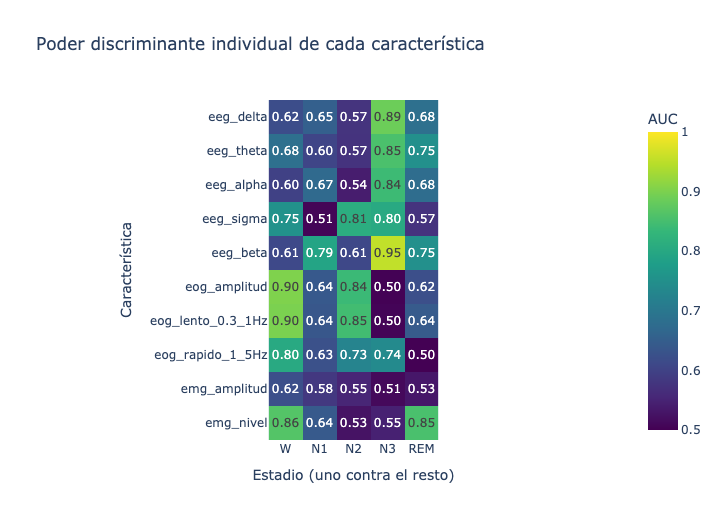

In [10]:
def auc(positivos, negativos):
    """AUC vía rangos (equivalente al estadístico de Mann-Whitney), sin dependencias extra.

    Se devuelve max(auc, 1-auc): interesa la magnitud de la separación, no su signo.
    """
    positivos = np.asarray(positivos)[~np.isnan(positivos)]
    negativos = np.asarray(negativos)[~np.isnan(negativos)]
    if len(positivos) < 10 or len(negativos) < 10:
        return np.nan
    rangos = rankdata(np.r_[positivos, negativos])
    a = (rangos[:len(positivos)].sum() - len(positivos) * (len(positivos) + 1) / 2) / (len(positivos) * len(negativos))
    return max(a, 1 - a)


columnas = [c for c in rasgos.columns if c.startswith(("eeg_", "eog_", "emg_"))]
tabla_auc = pd.DataFrame(
    {etapa: {c: auc(rasgos.loc[rasgos["etapa"] == etapa, c], rasgos.loc[rasgos["etapa"] != etapa, c])
             for c in columnas} for etapa in ORDEN}
).round(3)

fig = px.imshow(tabla_auc, text_auto=".2f", color_continuous_scale="Viridis", zmin=0.5, zmax=1.0,
                labels={"x": "Estadio (uno contra el resto)", "y": "Característica", "color": "AUC"},
                title="Poder discriminante individual de cada característica")
fig.update_layout(width=720, height=520)
fig.show()


El mapa reparte el trabajo entre las tres modalidades de una forma bastante clara, y no toda coincide
con lo que uno esperaría:

- **N3 es territorio del EEG**, como era de esperar: la banda beta llega a ≈0,95 y delta a ≈0,89,
  mientras que el mejor descriptor no-EEG se queda en ≈0,74.
- **REM es territorio del EMG.** El nivel medio del EMG alcanza ≈0,85 y es la característica
  individual más fuerte para esa clase, por encima de cualquier banda de EEG (≈0,75). Es la atonía
  muscular, el marcador clásico del REM.
- **El EOG resulta ser el mejor detector individual de vigilia (≈0,90) y de N2 (≈0,85)**, no de REM.
  Esto conviene leerlo con cuidado: el canal EOG horizontal está físicamente cerca del frontal y
  recoge bastante actividad cortical, así que parte de su poder discriminante probablemente no viene
  de los movimientos oculares sino de esa contaminación.
- **N1 se resiste a todas.** Su mejor característica individual apenas llega a ≈0,79 (beta del EEG) y
  ninguna modalidad la despeja. Es coherente con lo que vimos en la sección 2: es un estado de paso.

Vale la pena notar también el contraste entre los dos descriptores de EMG. El nivel medio (`emg_nivel`)
discrimina mucho mejor que la desviación estándar (`emg_amplitud`), porque la señal ya viene
rectificada por el equipo: lo informativo es su nivel absoluto —el tono muscular— y no su variabilidad.


## 3.4 El caso crítico: REM frente a N1


,AUC REM vs N1
emg_nivel,0.905
eeg_theta,0.613
eeg_beta,0.610
eog_rapido_1_5Hz,0.601
eeg_sigma,0.593
emg_amplitud,0.590
eog_lento_0.3_1Hz,0.522
eeg_alpha,0.521
eog_amplitud,0.506
eeg_delta,0.500


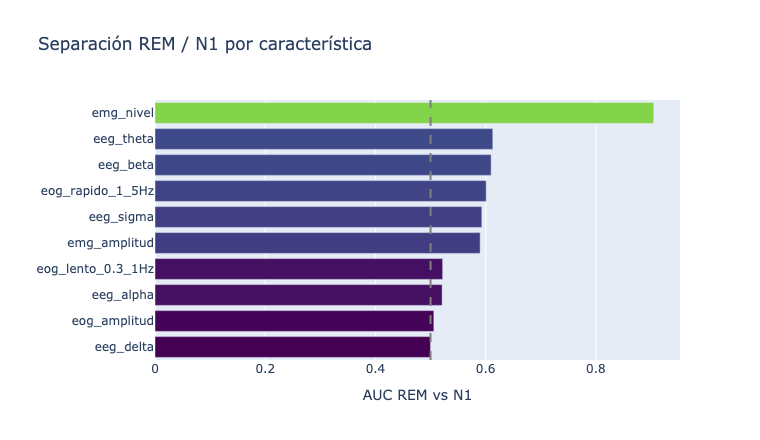

In [11]:
# N1 y REM comparten un EEG muy parecido (theta de bajo voltaje). Es la confusión que más castiga
# el F1 macro. Aquí se mide qué modalidad las separa.
subconjunto = rasgos[rasgos["etapa"].isin(["N1", "REM"])]
comparacion = pd.DataFrame({
    "AUC REM vs N1": {c: auc(subconjunto.loc[subconjunto["etapa"] == "REM", c],
                             subconjunto.loc[subconjunto["etapa"] == "N1", c]) for c in columnas}
}).round(3).sort_values("AUC REM vs N1", ascending=False)

display(comparacion)

fig = px.bar(comparacion.reset_index(), x="AUC REM vs N1", y="index", orientation="h",
             color="AUC REM vs N1", color_continuous_scale="Viridis", range_color=[0.5, 1.0],
             title="Separación REM / N1 por característica")
fig.update_layout(width=760, height=440, yaxis_title="", coloraxis_showscale=False,
                  yaxis={"categoryorder": "total ascending"})
fig.add_vline(x=0.5, line_dash="dash", line_color="grey")
fig.show()


El resultado es contundente y responde la pregunta con la que abrimos la sección: **el nivel del EMG
separa REM de N1 con un AUC de ≈0,90, mientras que ninguna otra característica —ni de EEG ni de EOG—
pasa de ≈0,61**. Es decir, la frontera que más castiga el F1 macro la resuelve una modalidad que hasta
ahora nadie había mirado, y la resuelve con una sola característica escalar.

Conviene ser explícito con la parte que **no** salió como esperaba. Yo entraba a esta sección
asumiendo que el EOG también ayudaría a marcar el REM, y los datos no lo respaldan: su mejor
descriptor en esta frontera (la potencia rápida de 1–5 Hz, ≈0,60) queda al mismo nivel que el mejor
EEG y muy lejos del EMG. Con un único canal horizontal y estos descriptores, el EOG no distingue REM
de N1. Hay dos explicaciones plausibles que
no puedo separar con este análisis. Una es que el criterio clínico clásico se basa en el desfase entre
**dos** canales de EOG, y Sleep-EDF solo trae uno, así que esa información sencillamente no está
disponible. La otra es que mis descriptores (desviación estándar y potencia en dos bandas anchas) sean
demasiado gruesos para capturar movimientos oculares que son eventos breves y esporádicos. Antes de
descartar el EOG habría que probar descriptores orientados a eventos —por ejemplo, conteo de
deflexiones que superen un umbral— y no promedios sobre toda la época.

**Recomendación para el equipo:** priorizar **EEG+EMG** como configuración de referencia, porque es la
combinación con evidencia clara a favor y es barata (el EMG aporta un escalar por época). Mantener el
EOG como entrada opcional según pide el enunciado, pero sin asumir que suma hasta que se pruebe con
descriptores mejores. Y dejar EEG solo como línea base y modo de respaldo.


# 4. Partición de los datos sin fuga de información

El enunciado exige partir por sujeto y no por época. Vale la pena medir qué pasaría si no se hiciera,
porque es un error fácil de cometer y difícil de detectar: el modelo simplemente reporta métricas
excelentes.


## 4.1 Cuánto se parecen dos épocas contiguas


In [12]:
espectrales = [c for c in rasgos.columns if c.startswith("eeg_")]
vecinas = rasgos.sort_values(["clave", "onset_s"]).copy()
for c in espectrales:
    vecinas[c + "_sig"] = vecinas.groupby("clave")[c].shift(-1)
vecinas = vecinas[np.isclose(vecinas.groupby("clave")["onset_s"].shift(-1) - vecinas["onset_s"],
                             DURACION_EPOCA)]

correlaciones = pd.Series({c: vecinas[c].corr(vecinas[c + "_sig"]) for c in espectrales}).round(3)
print("Correlación entre la época t y la época t+1 (misma noche):")
print(correlaciones.to_string())

# Referencia: la misma correlación entre épocas tomadas al azar del conjunto
azar = rasgos[espectrales].dropna()
mezcla = azar.sample(frac=1.0, random_state=0).reset_index(drop=True)
print("\nReferencia con épocas emparejadas al azar:")
print(pd.Series({c: azar[c].reset_index(drop=True).corr(mezcla[c]) for c in espectrales}).round(3).to_string())


Correlación entre la época t y la época t+1 (misma noche):
eeg_delta    0.748
eeg_theta    0.697
eeg_alpha    0.734
eeg_sigma    0.685
eeg_beta     0.698

Referencia con épocas emparejadas al azar:
eeg_delta   -0.000
eeg_theta   -0.005
eeg_alpha    0.002
eeg_sigma   -0.005
eeg_beta     0.007


Las características de dos épocas separadas por 30 segundos están correlacionadas alrededor de 0,7,
frente a una correlación nula cuando las épocas se emparejan al azar. No son observaciones idénticas,
pero están lejos de ser independientes: con una partición aleatoria por época, esas dos versiones casi
iguales caen en conjuntos distintos y el modelo termina evaluándose sobre información que ya vio.


## 4.2 Cuánta fuga produce una partición aleatoria por época


In [13]:
generador = np.random.default_rng(0)
orden = rasgos.sort_values(["clave", "onset_s"]).reset_index(drop=True)
es_prueba = generador.random(len(orden)) < 0.2

# ¿Cuántas épocas de prueba tienen una vecina inmediata de la misma noche en entrenamiento?
misma_noche = orden["clave"].to_numpy()
anterior_en_train = np.r_[False, (~es_prueba)[:-1] & (misma_noche[1:] == misma_noche[:-1])]
siguiente_en_train = np.r_[(~es_prueba)[1:] & (misma_noche[1:] == misma_noche[:-1]), False]
contaminadas = es_prueba & (anterior_en_train | siguiente_en_train)

print(f"Épocas en prueba: {es_prueba.sum():,}")
print(f"Con al menos una vecina inmediata en entrenamiento: {contaminadas.sum():,} "
      f"({contaminadas.sum() / es_prueba.sum():.1%})")
print(f"Sujetos presentes a la vez en entrenamiento y prueba: "
      f"{orden.loc[es_prueba, 'subject'].nunique()} de {orden['subject'].nunique()}")


Épocas en prueba: 2,527
Con al menos una vecina inmediata en entrenamiento: 2,465 (97.5%)
Sujetos presentes a la vez en entrenamiento y prueba: 6 de 6


Prácticamente toda la partición de prueba está contaminada. Y aunque se descartaran las vecinas, el
mismo sujeto seguiría apareciendo en ambos lados: el modelo puede aprender la firma individual del
EEG de esa persona en lugar de aprender a estadificar. Por eso la partición tiene que ser por sujeto.


## 4.3 Variabilidad entre sujetos y partición estratificada


Dispersión de la proporción de cada estadio entre sujetos:


etapa,W,N1,N2,N3,REM
min,0.124,0.018,0.152,0.000,0.038
50%,0.273,0.096,0.369,0.060,0.144
max,0.638,0.371,0.606,0.289,0.228
std,0.135,0.058,0.101,0.070,0.048


Sujetos sin ninguna época de N3: 6 de 78
Sujetos con menos del 2 % de N3: 26


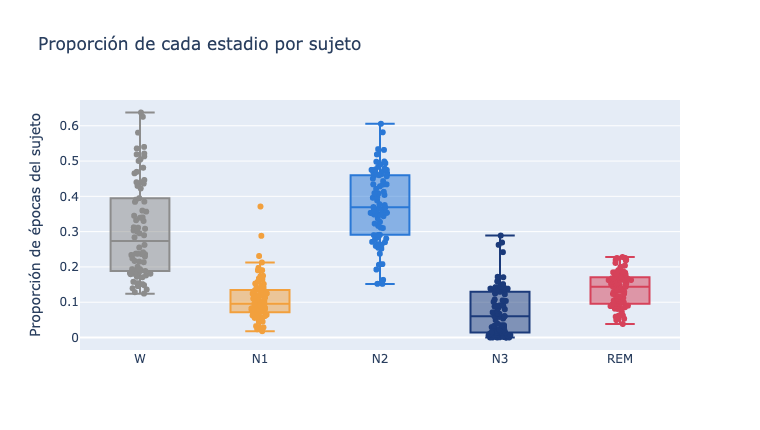

In [14]:
composicion = (pd.crosstab(epocas["subject"], epocas["etapa"], normalize="index")
               .reindex(columns=ORDEN, fill_value=0))

print("Dispersión de la proporción de cada estadio entre sujetos:")
display(composicion.describe().loc[["min", "50%", "max", "std"]].round(3))

print(f"Sujetos sin ninguna época de N3: {(composicion['N3'] == 0).sum()} de {len(composicion)}")
print(f"Sujetos con menos del 2 % de N3: {(composicion['N3'] < 0.02).sum()}")

fig = go.Figure()
for etapa in ORDEN:
    fig.add_box(y=composicion[etapa], name=etapa, marker_color=COLOR[etapa], boxpoints="all",
                jitter=0.4, pointpos=0)
fig.update_layout(width=760, height=430, showlegend=False,
                  title="Proporción de cada estadio por sujeto",
                  yaxis_title="Proporción de épocas del sujeto")
fig.show()


La composición del hipnograma varía mucho de un sujeto a otro, y el caso extremo es N3: hay sujetos
que no registran ninguna época de sueño profundo. Con particiones por sujeto y pocos sujetos por
pliegue, esa varianza se traslada directamente a la métrica —dos particiones igual de válidas pueden
diferir varios puntos de F1— y en el peor caso un pliegue de validación podría quedarse casi sin
ejemplos de una clase.

La partición debe entonces ser **por sujeto y estratificada**, y el resultado debe reportarse como
promedio sobre varios pliegues, no sobre una sola división.


In [15]:
def particion_por_sujeto(composicion, n_pliegues=5, semilla=0):
    """Reparte sujetos entre pliegues balanceando la proporción de N1, la clase más escasa.

    Se ordenan los sujetos por su proporción de N1 y se asignan en serpentina, de modo que cada
    pliegue reciba sujetos de todo el rango en lugar de concentrarse en un extremo.
    """
    ordenados = composicion.sort_values("N1").index.to_numpy()
    pliegues = {s: (i % n_pliegues if (i // n_pliegues) % 2 == 0
                    else n_pliegues - 1 - i % n_pliegues)
                for i, s in enumerate(ordenados)}
    return pd.Series(pliegues, name="pliegue")


asignacion = particion_por_sujeto(composicion, n_pliegues=5)
epocas_con_pliegue = epocas.merge(asignacion.rename_axis("subject").reset_index(), on="subject")

resumen = (epocas_con_pliegue.groupby("pliegue")
           .agg(sujetos=("subject", "nunique"), registros=("clave", "nunique"), epocas=("etapa", "size")))
proporciones = (pd.crosstab(epocas_con_pliegue["pliegue"], epocas_con_pliegue["etapa"], normalize="index")
                .reindex(columns=ORDEN, fill_value=0))
display(resumen.join(proporciones).round(3))

# Verificación explícita: ningún sujeto puede aparecer en dos pliegues
por_sujeto = epocas_con_pliegue.groupby("subject")["pliegue"].nunique()
assert (por_sujeto == 1).all(), "Hay sujetos repartidos entre pliegues"
print("Verificación superada: cada sujeto pertenece a exactamente un pliegue.")
print(f"Desviación de la proporción de N1 entre pliegues: {proporciones['N1'].std():.4f} "
      f"(entre sujetos era {composicion['N1'].std():.4f})")


,sujetos,registros,epocas,W,N1,N2,N3,REM
pliegue,,,,,,,,
0,15,29,34110,0.308,0.108,0.384,0.069,0.127
1,15,30,37931,0.320,0.101,0.345,0.098,0.135
2,16,32,41464,0.317,0.117,0.365,0.060,0.139
3,16,32,41965,0.364,0.108,0.336,0.062,0.129
4,16,30,40525,0.368,0.114,0.337,0.046,0.128


Verificación superada: cada sujeto pertenece a exactamente un pliegue.
Desviación de la proporción de N1 entre pliegues: 0.0062 (entre sujetos era 0.0580)


La asignación en serpentina reduce de forma apreciable la dispersión de la clase minoritaria entre
pliegues respecto a la dispersión natural entre sujetos, sin romper la restricción de no mezclar
sujetos. Es una función corta y reutilizable: conviene moverla al código común cuando se arme el
pipeline de entrenamiento.


# 5. Las etiquetas que no son estadios: `M` y `?`

El enunciado menciona una clase adicional `M` (movimiento) y un símbolo `?` para épocas sin
clasificar. Conviene saber cuánto pesan antes de decidir si el modelo tiene 5 o 6 salidas.


In [16]:
todas = pd.concat([s["completo"].assign(clave=c) for c, s in secuencias.items()], ignore_index=True)

conteo_total = todas["etapa"].value_counts()
conteo_ventana = epocas["etapa"].value_counts()

comparativa = pd.DataFrame({
    "registro completo": conteo_total,
    "ventana de sueño": conteo_ventana,
}).fillna(0).astype(int)
comparativa["% completo"] = (100 * comparativa["registro completo"] / comparativa["registro completo"].sum()).round(2)
comparativa["% ventana"] = (100 * comparativa["ventana de sueño"] / comparativa["ventana de sueño"].sum()).round(2)
display(comparativa.reindex(ORDEN + ["M", "?"]).fillna(0))

registros_con_m = todas[todas["etapa"] == "M"]["clave"].nunique()
print(f"Registros con al menos una época M: {registros_con_m} de {todas['clave'].nunique()}")
print(f"Épocas M: {(todas['etapa'] == 'M').sum():,}  |  épocas ?: {(todas['etapa'] == '?').sum():,}")


,registro completo,ventana de sueño,% completo,% ventana
etapa,,,,
W,285937,65942,64.89,33.64
N1,21522,21522,4.88,10.98
N2,69132,69132,15.69,35.27
N3,13039,13039,2.96,6.65
REM,25835,25835,5.86,13.18
M,128,128,0.03,0.07
?,25047,397,5.68,0.20


Registros con al menos una época M: 45 de 153


Épocas M: 128  |  épocas ?: 25,047


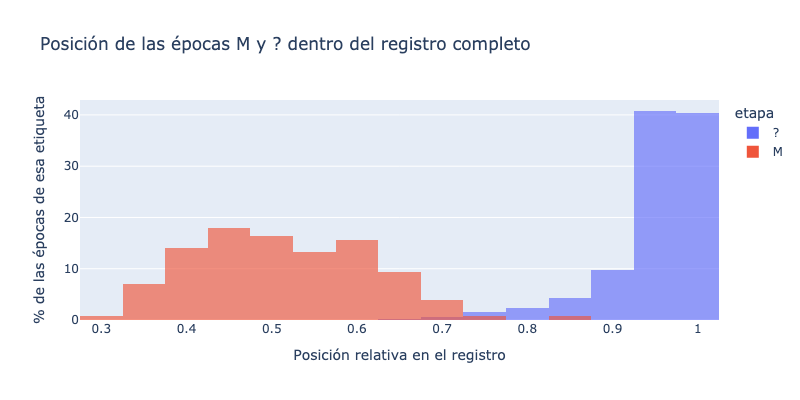

M: n=128  mediana de posición=0.49  en el último 20 % del registro=0.8 %


?: n=25,047  mediana de posición=0.97  en el último 20 % del registro=96.3 %


In [17]:
# ¿Dónde aparecen? Si '?' se concentra al final del registro, se trata de cola no anotada y
# descartarla no sesga nada; si estuviera repartida, sí habría que justificar el descarte.
posicion_especial = todas.copy()
posicion_especial["t_rel"] = posicion_especial.groupby("clave")["onset_s"].transform(
    lambda s: (s - s.min()) / max(s.max() - s.min(), 1))

fig = px.histogram(posicion_especial[posicion_especial["etapa"].isin(["M", "?"])],
                   x="t_rel", color="etapa", nbins=25, barmode="overlay", opacity=0.65,
                   histnorm="percent", title="Posición de las épocas M y ? dentro del registro completo")
fig.update_layout(width=800, height=400, xaxis_title="Posición relativa en el registro",
                  yaxis_title="% de las épocas de esa etiqueta")
fig.show()

for etiqueta in ("M", "?"):
    posiciones = posicion_especial.loc[posicion_especial["etapa"] == etiqueta, "t_rel"]
    print(f"{etiqueta}: n={len(posiciones):,}  mediana de posición={posiciones.median():.2f}  "
          f"en el último 20 % del registro={100 * (posiciones > 0.8).mean():.1f} %")


Las dos etiquetas se comportan de forma muy distinta y merecen decisiones distintas.

`?` pesa cerca del 6 % del registro completo, pero prácticamente todo eso está en la cola final del
archivo (la mediana de su posición está en el 97 % del registro) y casi desaparece al recortar la
ventana de sueño. Es material no anotado, no material ambiguo: descartarlo no introduce sesgo.

`M` es el caso opuesto: apenas un centenar de épocas en total, pero repartidas por el medio de la
noche, es decir, ocurren durante el sueño real. Son demasiado pocas para sostener una sexta clase
—el F1 macro se hundiría por una clase que el modelo casi nunca vería— pero no se pueden ignorar en
producción, porque la plataforma sí las va a encontrar. La recomendación es **entrenar con 5 clases y
tratar `M` como rechazo en inferencia**: un umbral de confianza o un detector de artefacto previo que
marque la época como no clasificable en lugar de forzar un estadio.


# 6. Hallazgos

1. **El hipnograma tiene memoria fuerte.** Cerca del 90 % de las épocas repiten el estadio de la época
   anterior y los episodios de REM y N2 se sostienen durante varios minutos. Formular el problema como
   clasificación independiente de épocas de 30 s desaprovecha esa estructura: conviene evaluar un
   modelo con contexto temporal, o como mínimo un suavizado posterior del hipnograma, y medir la
   ganancia frente a la línea base época a época.

2. **N1 y N3 son estados fragmentados.** N1 es el estadio menos persistente (≈0,72 frente a 0,91–0,95
   de los demás) y sus episodios tienen una mediana de 2 épocas; N3 aparece en tramos de una sola
   época que alternan con N2 (N3 → N2 es la transición fuera de la diagonal más frecuente). Esto
   explica por qué son las clases con peor F1 en la literatura, por qué el F1 macro es la métrica
   correcta —tal como pide el enunciado— y por qué cualquier suavizado del hipnograma debe ser
   conservador: una ventana ancha borraría episodios cortos que son reales.

3. **El EMG de Sleep-EDF está muestreado a 1 Hz.** No admite análisis espectral y debe tratarse como
   una envolvente de amplitud, no como una señal cruda equiparable al EEG. Es una restricción de
   arquitectura que hay que fijar antes de diseñar la red, no después.

4. **El EMG es el que resuelve la frontera REM/N1, y el EOG no.** El nivel medio del EMG separa REM de
   N1 con un AUC de ≈0,90, mientras que ninguna otra característica —de EEG o de EOG— pasa de ≈0,61 en
   esa frontera. Sugiero **EEG+EMG como configuración de referencia** —es la
   combinación con evidencia clara y el EMG cuesta un escalar por época— y dejar EEG solo como línea
   base. El EOG se mantiene como entrada opcional, según pide el enunciado, pero conviene reevaluarlo
   con descriptores orientados a eventos antes de asumir que aporta: con un solo canal horizontal y
   descriptores promediados sobre la época, aquí no aportó. Sí resultó ser, en cambio, el mejor
   detector individual de vigilia y de N2, probablemente por la actividad cortical que recoge.

5. **Partir por época sería un error silencioso.** Las características de dos épocas contiguas están
   correlacionadas alrededor de 0,7 (frente a 0,0 entre épocas al azar), y con una partición aleatoria
   al 20 % el 97,5 % de la partición de prueba tiene una vecina inmediata en entrenamiento. La
   partición debe ser por sujeto,
   estratificada por la proporción de N1, y validada con la comprobación explícita que quedó
   implementada en la sección 4.3. Hay además sujetos sin ninguna época de N3, así que conviene
   revisar la composición de cada pliegue antes de darlo por bueno.

6. **`?` se descarta sin riesgo; `M` merece otro trato.** `?` es cola no anotada del final del
   registro (mediana de posición en el 97 % del archivo). `M` ocurre durante el sueño real pero es
   demasiado escasa para sostener una sexta clase: propongo entrenar con 5 clases y manejar `M` como
   rechazo en inferencia.

**Siguiente paso propuesto para el equipo:** consolidar en un módulo común la extracción de
características por modalidad y la función de partición por sujeto de la sección 4.3, para que todos
los experimentos de modelado partan de la misma base y sean comparables entre sí.
